# Linear quantum annealing on the frustrated Ising ring — magic & entanglement

Tutorial notebook: run the plain LINEAR-ramp annealing protocol (no
optimal control) on this project's frustrated 1D Ising ring, and track
stabilizer Rényi entropy (magic, $M_2$) and bipartite entanglement entropy
along the trajectory.

This is the "baseline" protocol the project compares optimal control
against — see `study_1d_ising.py`'s "Protocol 1: LINEAR" section, which
this notebook reproduces in a self-contained, explained form.

**Pipeline:** `annealing_utils` builds $H_{\text{driver}}$/$H_{\text{target}}$
&rarr; `Z2SymmetricSector` projects both (and the initial state) into the
`sign=+1` sector &rarr; propagate with `expm_multiply` &rarr; `.lift()` each
$\psi(t)$ back to the full $2^n$ space &rarr; `SREJax` / `EntanglementEntropy`
compute $M_2(t)$ / $S_{vN}(t)$ there. See the companion
`ManyBodyQutip_tutorial.ipynb` for a deep dive on the first two steps.


## 0. Setup

In [1]:
import sys, os

REPO_ROOT = os.path.abspath(".")  # run from the repo root
sys.path.insert(0, REPO_ROOT)

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import expm_multiply, eigsh

from src.annealing_utils import get_driver_hamiltonian, get_longitudinal_hamiltonian
from src.utils import Z2SymmetricSector, EntanglementEntropy
from src.jax_utils import SREJax  # needs jax — see requirements.txt

np.set_printoptions(precision=4, suppress=True)

## 1. The antiferro Ising Ring

An antiferromagnetic ($J_{ij}>0$, since `get_longitudinal_hamiltonian`
returns $+\sum J_{ij}Z_iZ_j$) uniform-coupling ring cannot perfectly
alternate spin-up/spin-down when the number of sites $N$ is **odd** — two
neighboring sites are forced to share the same orientation somewhere on
the ring. That's the frustration this project studies (`N=7,9` per the
project notes). We use $N=6$ though, just to see how the code works without problems.


In [14]:
n = 6  # odd -> frustrated ring
jij = np.roll(np.eye(n), 1, axis=1) + np.roll(
    np.eye(n), -1, axis=1
)  # uniform AFM ring, J=1

H_driver = get_driver_hamiltonian(n)
H_target = get_longitudinal_hamiltonian(jij)
print("H_driver, H_target shapes:", H_driver.shape, H_target.shape)

H_driver, H_target shapes: (64, 64) (64, 64)


## 2. Z2 sector projection

Both Hamiltonians commute with the global spin flip $\Pi=\prod_i X_i$, and
the initial state $|+\rangle^{\otimes n}$ is a $+1$ eigenstate of $\Pi$ — so
we project everything into the `sign=+1` sector and work there (half the
dimension, exact — see `ManyBodyQutip_tutorial.ipynb` §4 for the full
derivation and the naive-`Sector`-is-wrong demonstration).


In [15]:
PS = Z2SymmetricSector(nqubits=n, sign=+1)
H_driver_s = PS.project(H_driver).astype(complex)
H_target_s = PS.project(H_target).astype(complex)

psi_init_full = np.ones(2**n, dtype=complex) / np.sqrt(2**n)
psi_init_s = PS.project(psi_init_full)

evals_gs_deg, evecs_gs_deg = eigsh(H_target_s, which="SA", k=10)
order = np.argsort(evals_gs_deg)
evals_gs_deg, evecs_gs_deg = evals_gs_deg[order], evecs_gs_deg[:, order]
gs_mask = evals_gs_deg < evals_gs_deg[0] + 1e-6
evals_gs, evecs_gs_manifold = evals_gs_deg[gs_mask], evecs_gs_deg[:, gs_mask]
print(
    f"target-Hamiltonian ground energy (sector): {evals_gs[0]:.4f}"
    f"  (degeneracy: {gs_mask.sum()} -- a frustration signature)"
)

Z2SymmetricSector: 32 states out of 64 (sign=+1)
target-Hamiltonian ground energy (sector): -6.0000  (degeneracy: 1 -- a frustration signature)


### A quick note on the gap

$H(s{=}1)$ is the bare classical ZZ Hamiltonian — for a frustrated
odd-$N$ ring its ground manifold is genuinely, exactly degenerate (a
hallmark of frustration, not a numerical artifact). The relevant spectral
gap for adiabaticity is therefore the INTERIOR gap (driver still present,
$s<1$), which we scan below — it decreases monotonically as $s\to1$
rather than closing at one isolated avoided-crossing point.


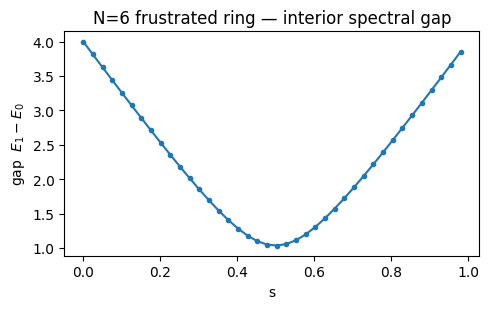

gap(s=0)=4.0000   gap(s~0.98)=3.8509


In [ ]:
svals = np.linspace(0.0, 0.98, 40)
gaps = np.zeros_like(svals)
for i, s in enumerate(svals):
    Hs = (1 - s) * H_driver_s + s * H_target_s
    ev, _ = eigsh(Hs, which="SA", k=2)
    ev = np.sort(ev)
    gaps[i] = ev[1] - ev[0]

plt.figure(figsize=(5, 3.2))
plt.plot(svals, gaps, marker=".")
plt.xlabel("s")
plt.ylabel("gap  $E_1-E_0$")
plt.title(f"N={n} ising ring — interior spectral gap")
plt.tight_layout()
plt.show()
print(f"gap(s=0)={gaps[0]:.4f}   gap(s~0.98)={gaps[-1]:.4f}")

## 3. Linear-ramp evolution

$H(t) = (1-t/\tau)\,H_{\text{driver}} + (t/\tau)\,H_{\text{target}}$,
propagated with piecewise-constant `expm_multiply` steps — same scheme
`SparseGRAPEModel`/`SchedulerModel` use internally, just without any
schedule ansatz on top (the ramp coefficients ARE $h_{\text{driver}}(t) =
1-t/\tau$, $h_{\text{target}}(t) = t/\tau$ directly).

We pick $\tau=20$ here — long enough that the linear ramp gets close to
(but not exactly at) the ground state, so the magic/entanglement dynamics
along the way are worth looking at.


In [17]:
tau = 10.0
nsteps = 100
tgrid = np.linspace(0, tau, nsteps)
dt = tgrid[1] - tgrid[0]

sre = SREJax(n_qubits=n, batch_size=1024)
ee = EntanglementEntropy(nqubits=n, n_A=n // 2)

psi = psi_init_s.copy()
energy_t = np.zeros(nsteps)
magic_t = np.zeros(nsteps)
entanglement_t = np.zeros(nsteps)

for i, t in enumerate(tgrid):
    Ht = (1 - t / tau) * H_driver_s + (t / tau) * H_target_s
    psi = expm_multiply(-1j * dt * Ht, psi)

    energy_t[i] = (psi.conj() @ H_target_s @ psi).real

    psi_full = PS.lift(psi)  # <-- leave the sector for these two
    magic_t[i] = sre(psi_full)
    entanglement_t[i] = ee.von_neumann(psi_full)

# population inside the (degenerate!) ground-state manifold, not a
# single-vector fidelity -- see the degeneracy note above.
gs_population = float(np.sum(np.abs(evecs_gs_manifold.conj().T @ psi) ** 2))

print(f"final energy      : {energy_t[-1]:.4f}   (GS = {evals_gs[0]:.4f})")
print(f"final population in GS manifold : {gs_population:.4f}")
print(f"final magic M2     : {magic_t[-1]:.4f}")
print(f"final entanglement : {entanglement_t[-1]:.4f}")

Building Pauli index tables for n=6 (4,096 Paulis)...
Done.
Bipartition: A=3 qubits (8d), B=3 qubits (8d)
final energy      : -5.5731   (GS = -6.0000)
final population in GS manifold : 0.8933
final magic M2     : 0.4404
final entanglement : 0.8198


## 4. Results

Energy converging toward the ground state while magic and entanglement
both rise sharply as the system passes through the region of small gap
(large $s$) and crosses through superposition over multiple
near-degenerate low-energy configurations — exactly the kind of
diagnostic-of-hardness signal this project's research investigates.


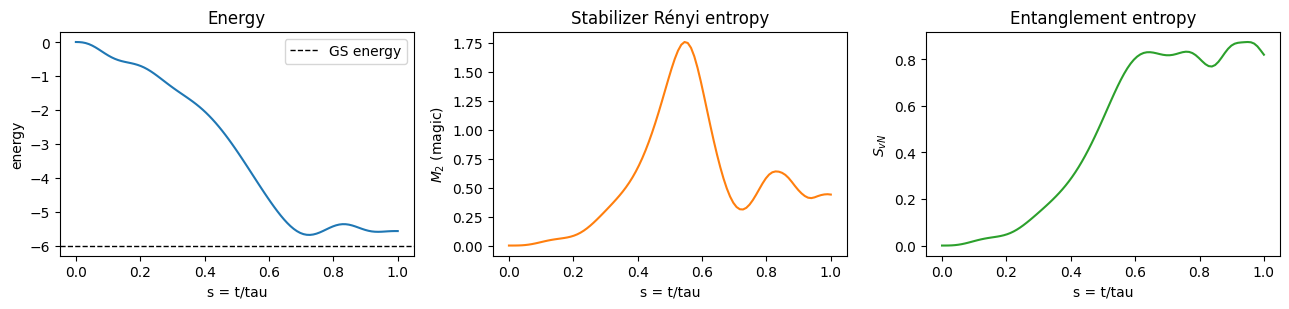

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))

axes[0].plot(tgrid / tau, energy_t)
axes[0].axhline(evals_gs[0], color="k", ls="--", lw=1, label="GS energy")
axes[0].set_xlabel("s = t/tau")
axes[0].set_ylabel("energy")
axes[0].legend()
axes[0].set_title("Energy")

axes[1].plot(tgrid / tau, magic_t, color="tab:orange")
axes[1].set_xlabel("s = t/tau")
axes[1].set_ylabel("$M_2$ (magic)")
axes[1].set_title("Stabilizer Rényi entropy")

axes[2].plot(tgrid / tau, entanglement_t, color="tab:green")
axes[2].set_xlabel("s = t/tau")
axes[2].set_ylabel("$S_{vN}$")
axes[2].set_title("Entanglement entropy")

plt.tight_layout()
plt.show()

## 5. Reference: instantaneous ground-state magic/entanglement

For context, the "ideal" curve any optimal-control protocol is implicitly
chasing: the magic/entanglement of the INSTANTANEOUS ground state of
$H(s)$ at each point along the ramp (no dynamics at all — just
diagonalize $H(s)$ and measure its ground state). This is the
counterdiabatic ideal referenced in the project's `study_1d_ising.py`.


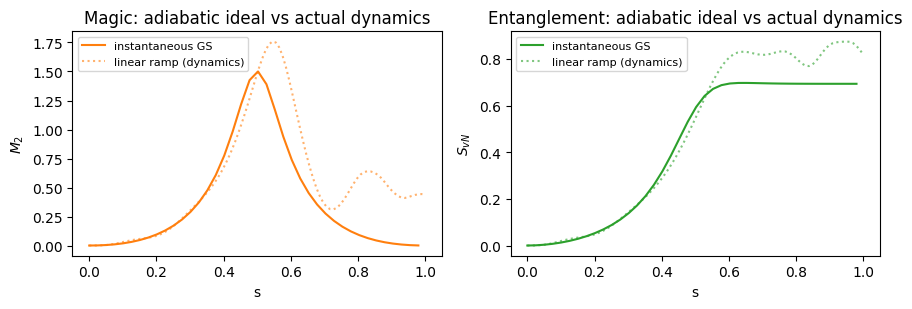

In [19]:
magic_gs = np.zeros(len(svals))
ee_gs = np.zeros(len(svals))
for i, s in enumerate(svals):
    Hs = (1 - s) * H_driver_s + s * H_target_s
    ev, evec = eigsh(Hs, which="SA", k=1)
    psi_gs_full = PS.lift(evec[:, 0])
    magic_gs[i] = sre(psi_gs_full)
    ee_gs[i] = ee.von_neumann(psi_gs_full)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].plot(svals, magic_gs, color="tab:orange", label="instantaneous GS")
axes[0].plot(
    tgrid / tau,
    magic_t,
    color="tab:orange",
    ls=":",
    alpha=0.6,
    label="linear ramp (dynamics)",
)
axes[0].set_xlabel("s")
axes[0].set_ylabel("$M_2$")
axes[0].legend(fontsize=8)
axes[0].set_title("Magic: adiabatic ideal vs actual dynamics")

axes[1].plot(svals, ee_gs, color="tab:green", label="instantaneous GS")
axes[1].plot(
    tgrid / tau,
    entanglement_t,
    color="tab:green",
    ls=":",
    alpha=0.6,
    label="linear ramp (dynamics)",
)
axes[1].set_xlabel("s")
axes[1].set_ylabel("$S_{vN}$")
axes[1].legend(fontsize=8)
axes[1].set_title("Entanglement: adiabatic ideal vs actual dynamics")

plt.tight_layout()
plt.show()

## 6. Takeaways

- The whole trajectory lived in the 64-dimensional `sign=+1` sector; magic
  and entanglement were only computed after `.lift()`-ing back to the full
  128-dimensional space, since neither observable respects the sector
  block structure the way a Hamiltonian expectation value does.
- At $\tau=20$ the linear ramp already tracks the instantaneous-ground-state
  curve reasonably well but not exactly — the gap between the dotted
  (actual dynamics) and solid (adiabatic ideal) curves is exactly the
  diabatic error this project's optimal-control methods are trying to
  correct for at SHORTER $\tau$. See
  `Optimal_control_schedule_tutorial.ipynb` for that comparison at a $\tau$
  where linear ramp performs noticeably worse.
- Here the entanglement is not zero because of the Z2 symmetry where the Hilbert space is defined, there is a degeneracy that leads to a non-zero entanglement.
